In [ ]:
# 1. Identificación y justificación de técnicas de tratamiento:
# • Expliquen cómo el tratamiento de datos faltantes asegura la integridad de los datos para su posterior uso en algoritmos de
# machine learning.
# • Presenten ejemplos de cómo la técnica seleccionada afectó positivamente el conjunto de datos procesado.
# 2. Técnicas empleadas para la normalización y estandarización con su justificación:
# • Proporcionen ejemplos de cómo el escalamiento estandarizó las variables y permitió un desempeño sin errores de los
# algoritmos.
# • Presenten visualizaciones (antes y después del escalamiento) que demuestren la transformación de los datos.
# 3. Técnicas de codificación:
# • Detallen las técnicas empleadas (Label Encoding, One-Hot Encoding, Ordinal Encoding y categorical encoding).
# • Justifiquen por qué se seleccionó una técnica específica según las características de las variables categóricas y el modelo.
# 4. Proceso de creación de nuevas variables:
# • Expliquen las técnicas aplicadas (agregaciones, transformaciones matemáticas, interacciones entre variables, etc.).
# • Justifiquen cómo estas nuevas variables aportan valor al análisis y mejoran el rendimiento del modelo.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from sklearn.impute import KNNImputer
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer

from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import RobustScaler

In [2]:
df = pd.read_csv("bank-additional-full.csv", sep=';')

In [29]:
df.shape

(41188, 20)

In [4]:
df.head(2)

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


Informacion de las variables

In [ ]:
# 1 - edad (numerico)
# 2 - trabajo: tipo de trabajo (categorico: "administrador", "obrero", "empresario", "empleado domestico",
#     "gerente", "jubilado", "autonomo", "servicios", "estudiante", "tecnico", "desempleado", "desconocido")
# 3 - estado civil: estado civil (categorico: "divorciado", "casado", "soltero", "desconocido";
#     nota: "divorciado" significa divorciado o viudo)
# 4 - educacion (categorico: "basico.4a", "basico.6a", "basico.9a", "bachillerato", "analfabeto",
#     "curso profesional", "titulo universitario", "desconocido")
# 5 - mora: tiene credito en mora? (categorico: "no", "si­", "desconocido")
# 6 - vivienda: ¿tiene prestamo para vivienda? (categorico: "no", "si­", "desconocido")
# 7 - prestamo: ¿tiene prestamo personal? (categorico: "no", "si­", "desconocido")

# Relacionado con el ultimo contacto de la campaña actual:
# 8 - contacto: tipo de comunicacion del contacto (categorico: "celular", "telefono")
# 9 - mes: mes del año del ultimo contacto (categorico: "ene", "feb", "mar", ..., "nov", "dic")
# 10 - dia_de_la_semana: di­a de la semana del ultimo contacto (categorico: "mon", "tue", "wed", "thu", "fri")
# 11 - duracion: duracion del ultimo contacto, en segundos (numerico).
# Nota importante: este atributo afecta en gran medida el objetivo de salida
# (p. ej., si duracion=0 entonces y="no"). Sin embargo, la duracion no se conoce antes de que se realice una llamada. Ademas,
# despues del final de la llamada, obviamente se conoce y. Por lo tanto, esta entrada solo se debe incluir con fines de referencia
# y se debe descartar si la intencion es tener un modelo predictivo realista.

# Otros atributos:
# 12 - campaña: numero de contactos realizados durante esta campaña y para este cliente (numerico, incluye el ultimo contacto)
# 13 - pdays: numero de di­as transcurridos desde que el cliente fue contactado por ultima vez de una campaña anterior (numerico; 999 significa que el cliente no fue contactado previamente)
# 14 - anterior: numero de contactos realizados antes de esta campaña y para este cliente (numerico)
# 15 - poutcome: resultado de la campaña de marketing anterior (categorico: "fracaso", "inexistente", "exito")

# Atributos de contexto social y economico
# 16 - emp.var.rate: tasa de variacion del empleo - indicador trimestral (numerico)
# 17 - cons.price.idx: indice de precios al consumidor - indicador mensual (numerico)
# 18 - cons.conf.idx: i­ndice de confianza del consumidor - indicador mensual (numerico)
# 19 - euribor3m: tasa del euribor a 3 meses - indicador diario (numerico)
# 20 - nr.employed: numero de empleados

## Limpieza de variables no relevantes
* duracion

Como se menciona en la descripcion de las variables, la duracion es un dato que solo se obtiene al finalizar la llamada y al finalizarla ya se sabe el resultado de "y", por lo que es inutil predecir en base a ese dato ya que no se tendria la duracion, evitando el Data Leakage

In [12]:
df = df.drop(columns=['duration'])

## Busqueda de MV (valores nulos o bajo otros terminos como "unknow")

Listado de los valores unicos en cada variable
<br>Util para detectar valores MV que no estan definidos como Nan pero si bajo otros terminos como unknown

In [9]:
lista = df.columns.tolist()

for i in lista:
  print(i)
  print(df[i].unique())

age
[56 57 37 40 45 59 41 24 25 29 35 54 46 50 39 30 55 49 34 52 58 32 38 44
 42 60 53 47 51 48 33 31 43 36 28 27 26 22 23 20 21 61 19 18 70 66 76 67
 73 88 95 77 68 75 63 80 62 65 72 82 64 71 69 78 85 79 83 81 74 17 87 91
 86 98 94 84 92 89]
job
['housemaid' 'services' 'admin.' 'blue-collar' 'technician' 'retired'
 'management' 'unemployed' 'self-employed' nan 'entrepreneur' 'student']
marital
['married' 'single' 'divorced' nan]
education
['basic.4y' 'high.school' 'basic.6y' 'basic.9y' 'professional.course' nan
 'university.degree' 'illiterate']
default
['no' nan 'yes']
housing
['no' 'yes' nan]
loan
['no' 'yes' nan]
contact
['telephone' 'cellular']
month
['may' 'jun' 'jul' 'aug' 'oct' 'nov' 'dec' 'mar' 'apr' 'sep']
day_of_week
['mon' 'tue' 'wed' 'thu' 'fri']
duration
[ 261  149  226 ... 1246 1556 1868]
campaign
[ 1  2  3  4  5  6  7  8  9 10 11 12 13 19 18 23 14 22 25 16 17 15 20 56
 39 35 42 28 26 27 32 21 24 29 31 30 41 37 40 33 34 43]
pdays
[999   6   4   3   5   1   0  10   7   8 

Luego de encontrar valores MV, al ser solo unknown, leemos de nuevo el dataSet marcando los unknown como nan para luego limpiar los datos

In [27]:
df = pd.read_csv("bank-additional-full.csv", sep=';', na_values='unknown')
df = df.drop(columns=['duration']) # Recordar que se elimina duracion para evitar Data Leakage

In [28]:
for i in range(df.shape[1]):
  n_miss = int(df.iloc[:, i].isnull().sum())
  perc = round(n_miss / df.shape[0] * 100,1)
  if n_miss > 0: # Trae solo las variables con nulos, evita mostrar muchos datos inecesarios
    t = "{0} - {1}  =  Missing: {2} ({3}%)".format(i, df.columns[i], n_miss, perc)
    print(t)

1 - job  =  Missing: 330 (0.8%)
2 - marital  =  Missing: 80 (0.2%)
3 - education  =  Missing: 1731 (4.2%)
4 - default  =  Missing: 8597 (20.9%)
5 - housing  =  Missing: 990 (2.4%)
6 - loan  =  Missing: 990 (2.4%)


Ya que default y education son variables significativas porcentualmente en MV, mientras que job, marital, housing y loan, son MV porcentualmente muy bajos, como equipo consideramos analizar el tipo de MV que es education y default, para saber como imputarlos, y las demas variables imputarlas de forma simple ya que no generaran un sesgo significativo en la data

## Clasificacion tipo de MV
* education(Nivel Educativo)
<br>Resultado =

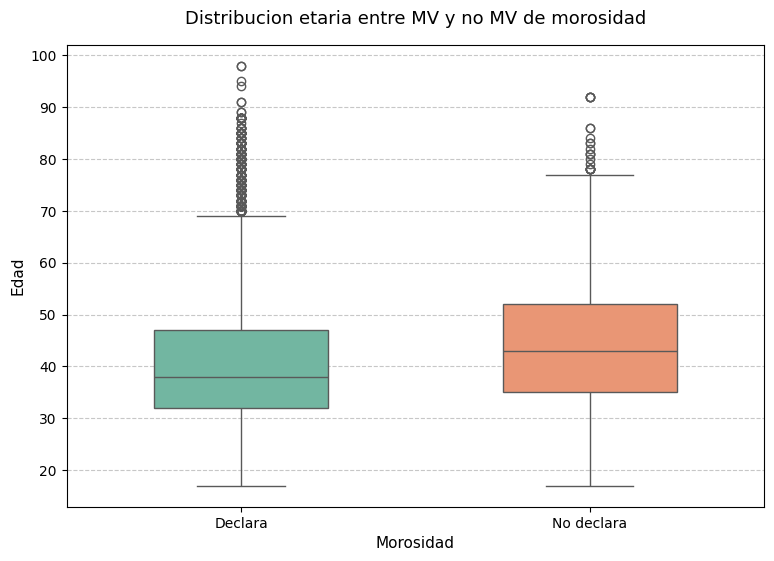

In [31]:
df['Estado'] = df['education'].apply(lambda x: 'No declara' if True == pd.isna(x) else 'Declara')

plt.figure(figsize=(9, 6))
sns.boxplot(data=df,
            x='Estado',
            y='age',
            palette='Set2',
            hue='Estado',
            width=0.5)

plt.title('Distribucion etaria entre MV y no MV de morosidad', fontsize=13, pad=15)
plt.xlabel('Morosidad', fontsize=11)
plt.ylabel('Edad', fontsize=11)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

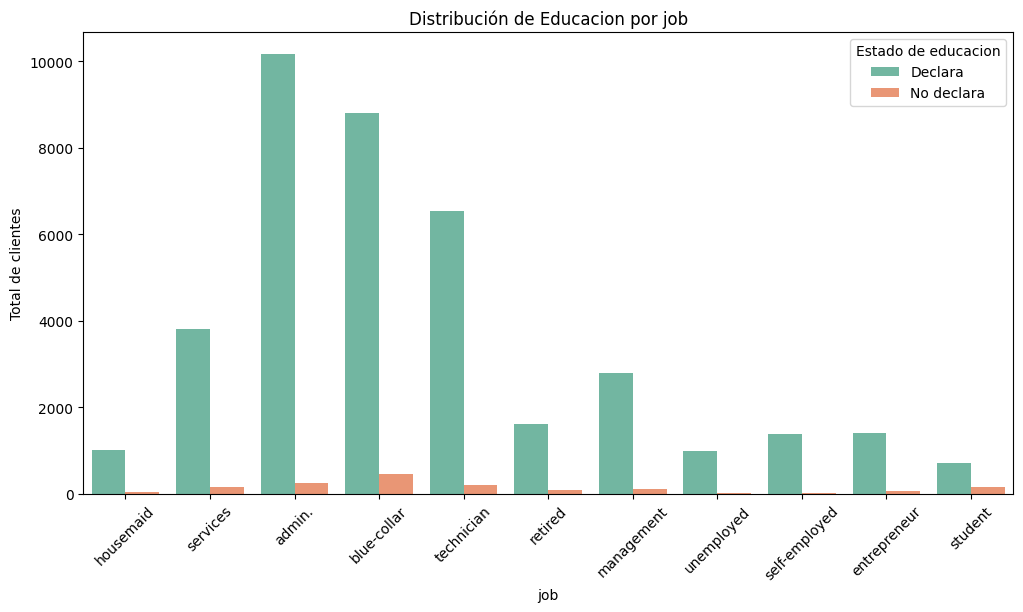

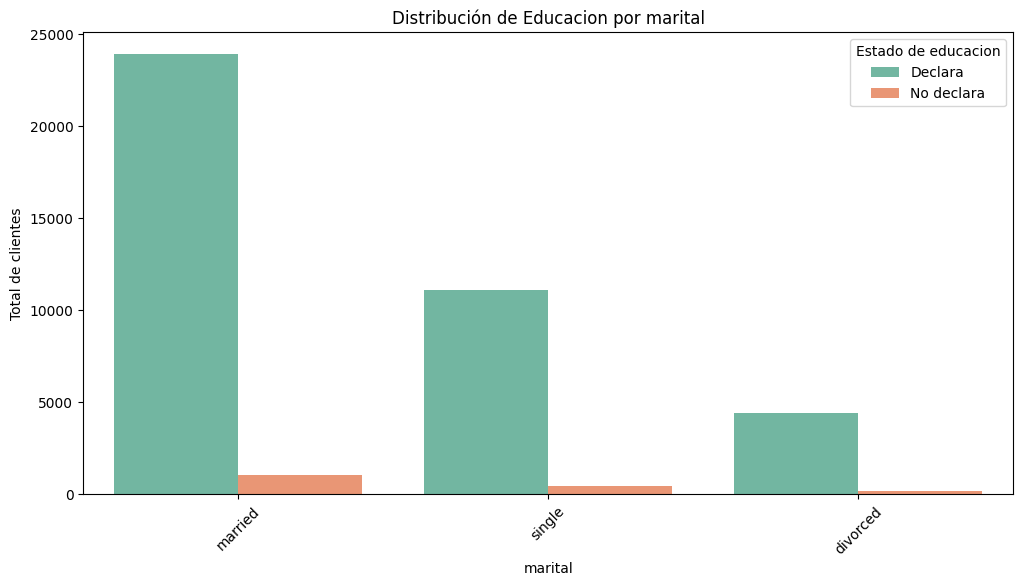

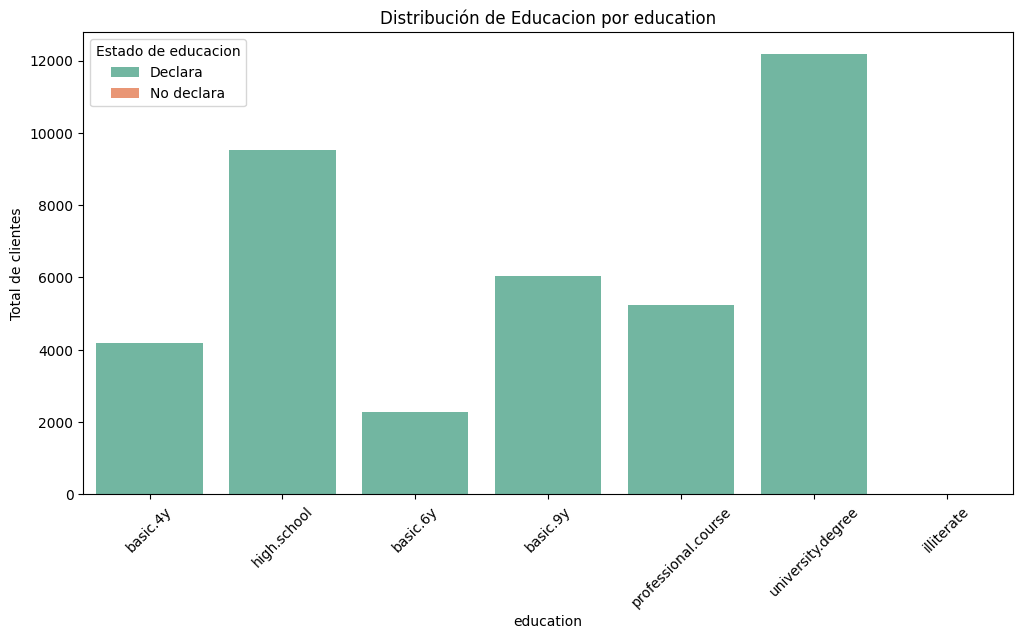

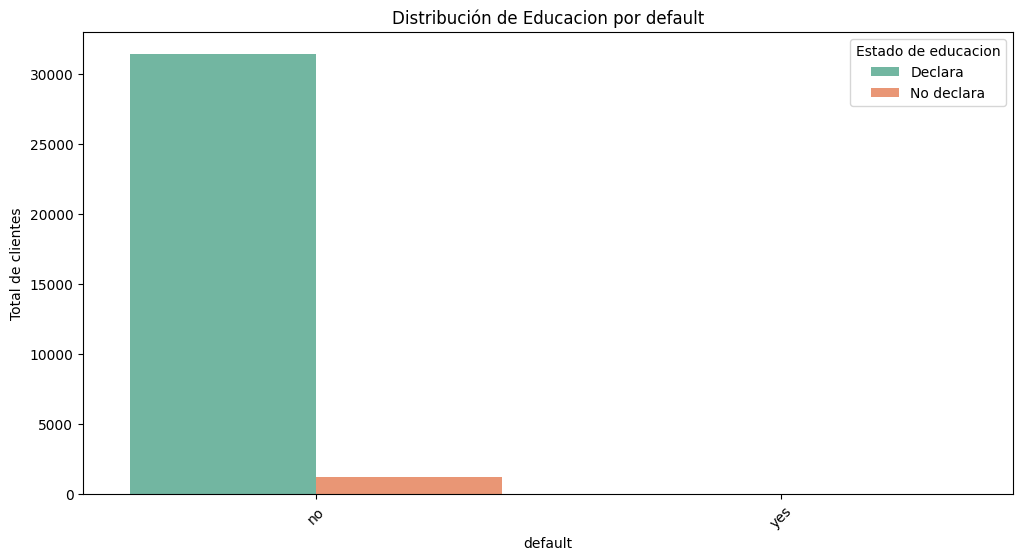

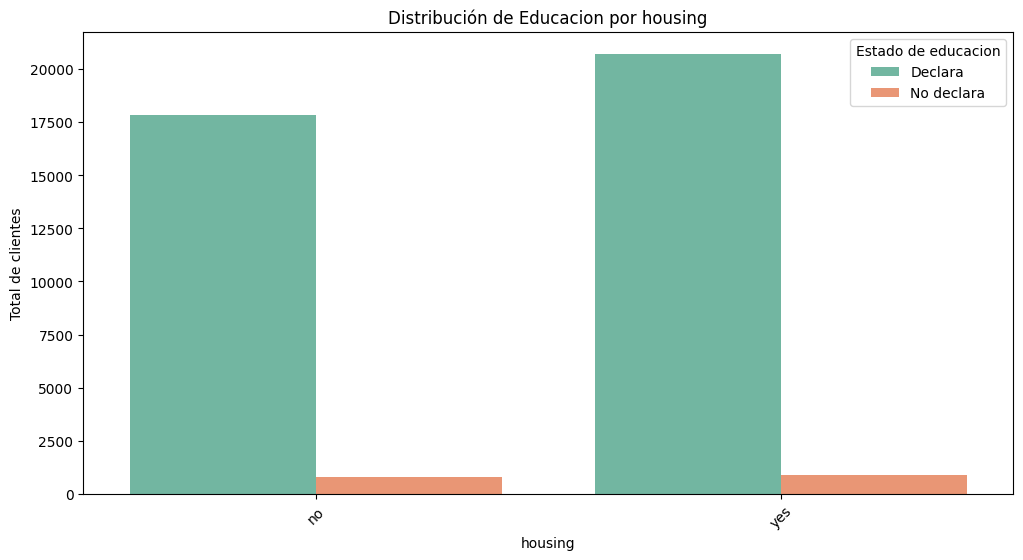

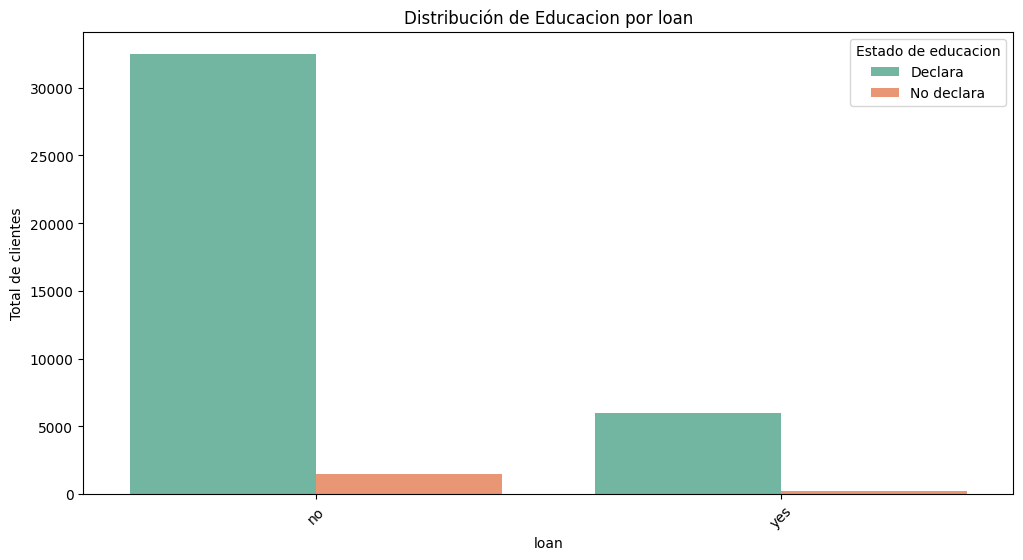

In [33]:
# "job", "marital", "education", "default", "housing", "loan"
df['Estado'] = df['education'].apply(lambda x: 'No declara' if True == pd.isna(x) else 'Declara')
variables = ["job", "marital", "education", "default", "housing", "loan"]
for i in variables:

  plt.figure(figsize=(12, 6))
  sns.countplot(data=df,
                x=f'{i}',
                hue='Estado',
                palette='Set2')

  plt.title(f'Distribución de Educacion por {i}')
  plt.ylabel("Total de clientes")
  plt.xlabel(f"{i}")
  plt.xticks(rotation=45)
  plt.legend(title='Estado de educacion')
  plt.show()
  print("\n")

## Clasificacion tipo de MV
* default(Morosidad)
<br>Resultado = MAR

Analisis preventivo

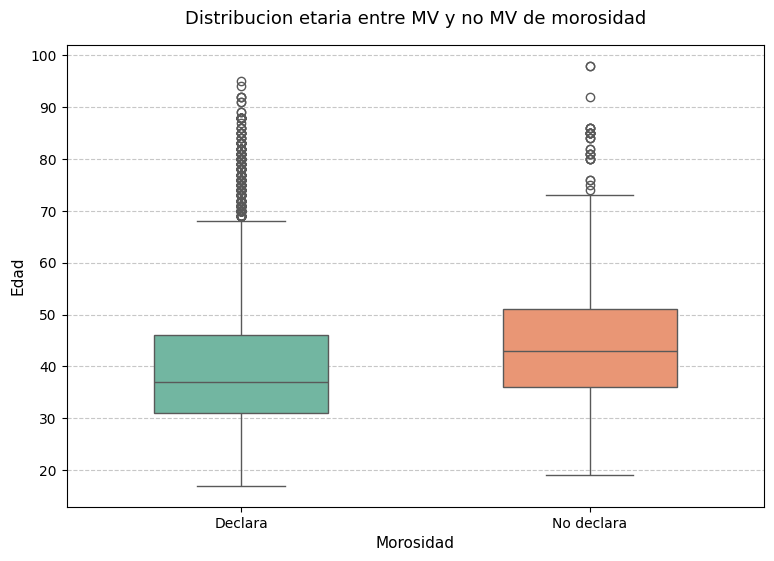

In [25]:
df['Estado'] = df['default'].apply(lambda x: 'No declara' if True == pd.isna(x) else 'Declara')

plt.figure(figsize=(9, 6))
sns.boxplot(data=df,
            x='Estado',
            y='age',
            palette='Set2',
            hue='Estado',
            width=0.5)

plt.title('Distribucion etaria entre MV y no MV de morosidad', fontsize=13, pad=15)
plt.xlabel('Morosidad', fontsize=11)
plt.ylabel('Edad', fontsize=11)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

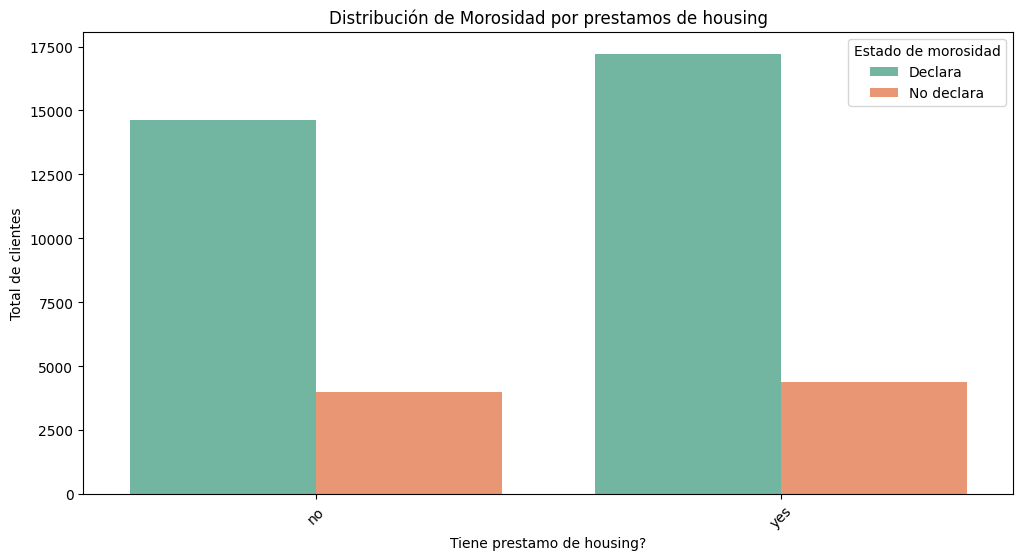

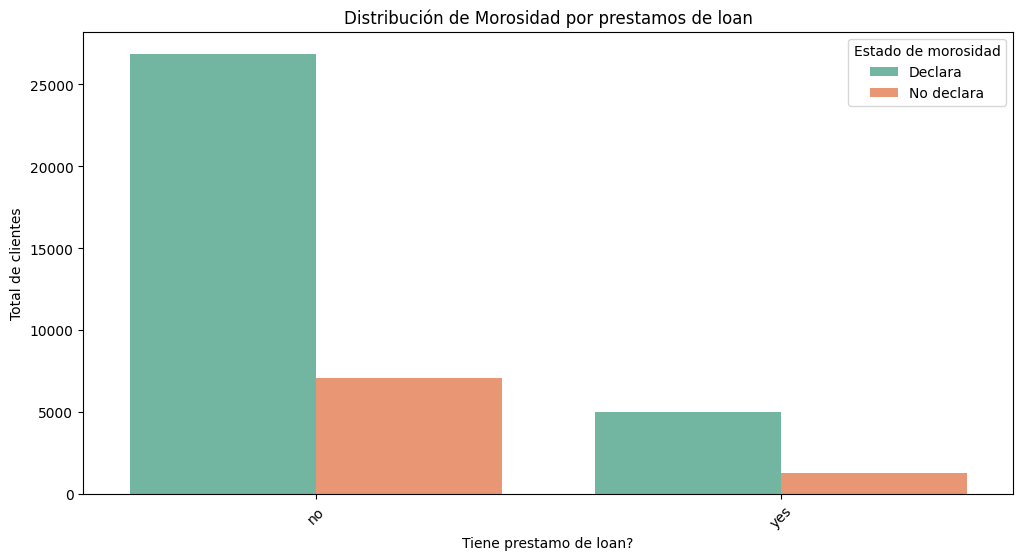

In [16]:
df['Estado'] = df['default'].apply(lambda x: 'No declara' if True == pd.isna(x) else 'Declara')
variables = ["housing", "loan"] # Variables que se descubrio que tienen relacion con default(morosidad)
for i in variables:

  plt.figure(figsize=(12, 6))
  sns.countplot(data=df,
                x=f'{i}',
                hue='Estado',
                palette='Set2')

  plt.title(f'Distribución de Morosidad por prestamos de {i}')
  plt.ylabel("Total de clientes")
  plt.xlabel(f"Tiene prestamo de {i}?")
  plt.xticks(rotation=45)
  plt.legend(title='Estado de morosidad')
  plt.show()
  print("\n")

Se puede observar que existe relacion entre morosidad y loan(prestamo personal), donde la mayoria de personas que no marco un valor en default(morosidad) no declara tener un prestamo, en cuanto a housing(prestamo de vivienda), la cantidad es equitativa, por lo que se deduce que es un MV de tipo MAR, asumiendo que aproximadamente la mitad de los clientes que no marco morosidad , se puede deber al prestamo de vivienda